In [1]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
hiden_size = 100
block_size = 3 # contect window size: how many characters do we take to predict the next one
embedding_size = 2

In [3]:
with open('names.txt', 'r') as f:
    words = f.read().splitlines()

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
X, Y = [], []


for w in words[:]:
    # print(w)
    context  = [0] * block_size
    for ch in w + '.':
        id = stoi[ch]
        X.append(context)
        Y.append(id)
        # print(''.join([itos[c] for c in context]), f' ---> {itos[id]}')
        context = context[1:] + [id]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([228146, 3]), torch.Size([228146]), torch.int64, torch.int64)

In [8]:
C = torch.randn((27, embedding_size)) # character embedding table

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @  C

tensor([-1.0977, -0.2030])

In [10]:
emb  = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [11]:
W1 = torch.randn((embedding_size * block_size, hiden_size)) 
b1 = torch.randn(hiden_size)
W2 = torch.randn((hiden_size , 27))
b2 = torch.randn(27)

In [12]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [13]:
logits = h @ W2 + b2
counts = logits.exp()

In [14]:
prob = counts/counts.sum(1, keepdims = True)

In [15]:
prob.shape

torch.Size([228146, 27])

In [16]:
prob[0].sum()

tensor(1.0000)

In [17]:
loss = -prob[torch.arange(len(Y)), Y].log().mean()
loss

tensor(17.1250)

### Rewriting

In [59]:
lr = 0.001

In [36]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embedding_size), generator = g) # character embedding table
W1 = torch.randn((embedding_size * block_size, hiden_size), generator = g )
b1 = torch.randn(hiden_size, generator = g)
W2 = torch.randn((hiden_size , 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, W2, b1, b2]


In [37]:
sum(p.nelement()for p in parameters) 

3481

In [ ]:
for p in parameters:
    p.requires_grad = True


2.33676815032959


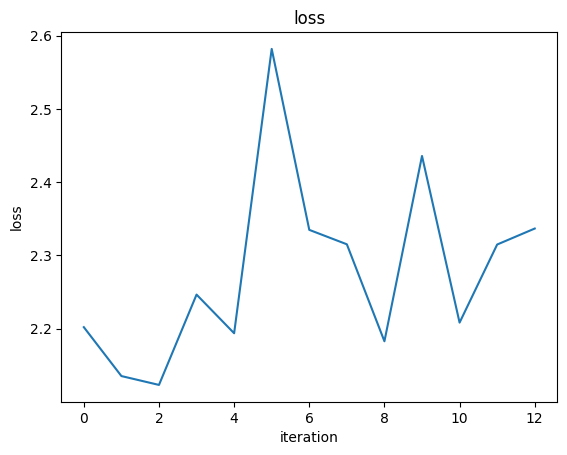

In [62]:
try:
    len(final_loss)
except NameError:
    final_loss = []
for _ in range(10_000):

    # mini-batch gradient descent
    ix = torch.randint(0, X.shape[0], (64,))

    # forward pass
    emb  = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -lr* p.grad
final_loss.append(loss.item())
print(loss.item())
plt.plot(final_loss)
plt.title('loss')
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()

In [56]:
emb  = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.2844, grad_fn=<NllLossBackward0>)

To find an optimal find a small and one that explode. Then do expodential step between the 2. Then for each epoch increase the learning rate. And plot the lr and loss. And get a learning rate that is in the knee.

In [ ]:
lre = torch.linspace(-3, 1, 1000)
lrs = 10**lre
lri = []
lossi = []
for p in parameters:
    p.requires_grad = True
for i in range(1000):

    # mini-batch gradient descent
    ix = torch.randint(0, X.shape[0], (64,))

    # forward pass
    emb  = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -lrs[i]* p.grad 

    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

63.47632598876953


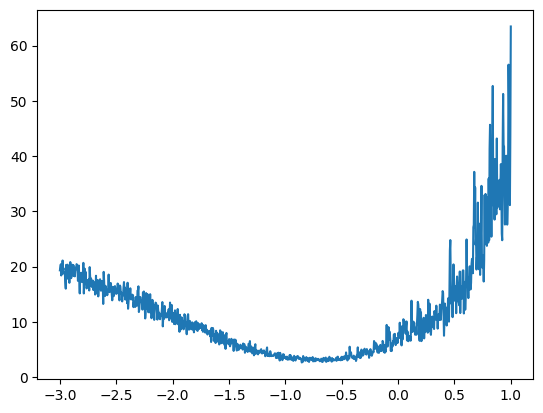

In [33]:
plt.plot(lri, lossi)

Here the optimal will be between [10**-1, 10**-.5]

## Splitting 
- train: 80% 
- val: 10%
- test: 10%

In [63]:
def build_dataset(words, block_size, verbose=False):
    X, Y = [], []

    for w in words[:]:
        # print(w)
        context  = [0] * block_size
        for ch in w + '.':
            id = stoi[ch]
            X.append(context)
            Y.append(id)
            # print(''.join([itos[c] for c in context]), f' ---> {itos[id]}')
            context = context[1:] + [id]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    if verbose:
        print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:n1], block_size, verbose=True)
Xval, Yval = build_dataset(words[n1:n2], block_size, verbose=True)
Xtest, Ytest = build_dataset(words[n2:], block_size, verbose=True)


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [64]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embedding_size), generator = g) # character embedding table
W1 = torch.randn((embedding_size * block_size, hiden_size), generator = g )
b1 = torch.randn(hiden_size, generator = g)
W2 = torch.randn((hiden_size , 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, W2, b1, b2]

In [67]:
for p in parameters:
    p.requires_grad = True

In [ ]:

for _ in range(100_000):

    # mini-batch gradient descent
    ix = torch.randint(0, Xtrain.shape[0], (64,))

    # forward pass
    emb  = C[Xtrain[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytrain[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -lr* p.grad
# final_loss.append(loss.item())
print(loss.item())
# plt.plot(final_loss)
# plt.title('loss')
# plt.xlabel('iteration')
# plt.ylabel('loss')
# plt.show()

In [ ]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss.item()